In [9]:
import xarray as xr
import pandas as pd
import numpy as np
import numpy.ma as ma
import matplotlib.pyplot as plt
from matplotlib.colors import CenteredNorm
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr, spearmanr, wasserstein_distance
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import classification_report, jaccard_score, cohen_kappa_score
from scipy import stats

In [10]:
target_res = 0.125
min_lon, min_lat, max_lon, max_lat =[-61.0, -47.5, -60.0, -44.875]
# min_lon_global, min_lat_global, max_lon_gloabl, max_lat_global = [-69.61, -60., -50., -32.45] #bbox of our study
min_time, max_time = pd.to_datetime("2013-01-01"), pd.to_datetime("2025-12-31")

fishing_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp="HKP")
fishing = fishing_ds["cpue_index"]
fishing = fishing.fillna(0)

fishing_class_ds = xr.open_dataset(f"../data/processed/targets/cpue_{target_res}.nc").sel(FAOspp="SQA")
fishing_class = fishing_class_ds["CPUE_class"]
fishing_class = fishing_class.fillna(0)

mask_ds = xr.open_dataset(f"../data/processed/static/area_pesca_{target_res}.nc")
mask = mask_ds["mask"]
mask = mask.fillna(0)
mask = mask.broadcast_like(fishing)

fishing, mask = xr.align(fishing, mask, join="inner")

#area de pesca y un poco alrededor
croppedT = lambda da: da.sel(
    lon=slice(min_lon-0.5, max_lon+0.5),
    lat=slice(min_lat-0.5, max_lat+0.5),
    time=slice(min_time, max_time)
)
fishing_cropped = croppedT(fishing)
mask_cropped = croppedT(mask)
fishing_class_cropped = croppedT(fishing_class)


In [11]:
# 2. Train/Test Split (Split year 2020)
split_date = "2023-01-01"
fishing_train = fishing_cropped.sel(time=slice(None, split_date))
fishing_test = fishing_cropped.sel(time=slice(split_date, None))
mask_test = mask_cropped.sel(time=slice(split_date, None))

# 3. Build the Climatology Model (Monthly means from the training set)
climatology = fishing_train.groupby("time.month").mean("time")

# 4. Predict on the Test Period
# Map the monthly climatology back to the specific dates of the test set
fishing_pred = climatology.sel(month=fishing_test.time.dt.month).drop_vars("month")

In [12]:
def compute_climatology_metrics_regression(y_true_da, y_pred_da, mask_da):
    # =====================================================
    # 1. EXTRACT ARRAYS & FLATTEN FOR METRICS
    # =====================================================
    # Extract underlying numpy arrays
    y_true = y_true_da.values
    y_pred = y_pred_da.values
    mask_spatial = mask_da.values > 0  # Ensure boolean
    
    # Broadcast 2D mask to 3D time series if necessary
    if mask_spatial.ndim == 2:
        mask_spatial = np.broadcast_to(mask_spatial, y_true.shape)

    # Flatten for global sklearn metrics
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    mask_flat = mask_spatial.flatten()
    
    y_test_masked = y_true_flat[mask_flat]
    y_pred_masked = y_pred_flat[mask_flat]

    # Clean NaNs strictly for valid indices (just in case they slipped through)
    valid = ~np.isnan(y_test_masked) & ~np.isnan(y_pred_masked)
    y_test_masked = y_test_masked[valid]
    y_pred_masked = y_pred_masked[valid]

    # =====================================================
    # 2. REGRESSION METRICS
    # =====================================================
    rmse = np.sqrt(mean_squared_error(y_test_masked, y_pred_masked))
    mae = mean_absolute_error(y_test_masked, y_pred_masked)
    r2 = r2_score(y_test_masked, y_pred_masked)
    pearson_corr = pearsonr(y_test_masked, y_pred_masked)[0]
    mbe = np.mean(y_pred_masked - y_test_masked)
    data_range_flat = np.max(y_test_masked) - np.min(y_test_masked)
    nrmse = rmse / data_range_flat if data_range_flat > 0 else 0

    w_dist = wasserstein_distance(y_test_masked, y_pred_masked)
    spearman_corr, p_val = spearmanr(y_test_masked, y_pred_masked)

    print("RMSE:", f"{rmse:.4f}")
    print(f"Normalized RMSE: {nrmse:.4f} ({nrmse*100:.2f}%)")
    print("MAE:", f"{mae:.4f}")
    print("R2:", f"{r2:.4f}")
    print("Pearson R:", f"{pearson_corr:.4f}")
    print("MBE:", f"{mbe:.4f}")
    print(f"Wasserstein Distance: {w_dist:.4f}")
    print(f"Spearman Rank Correlation: {spearman_corr:.2f}")

    # =====================================================
    # 3. GLOBAL HOTSPOT Hit Rate (Top-K Overlap)
    # =====================================================
    percentile = 80
    hotspot_threshold_true = np.percentile(y_test_masked, percentile)
    hotspot_threshold_pred = np.percentile(y_pred_masked, percentile)

    actual_hotspots = (y_test_masked >= hotspot_threshold_true)
    pred_hotspots = (y_pred_masked >= hotspot_threshold_pred)

    total_actual_hotspots = np.sum(actual_hotspots)
    shared_hotspots = np.sum(actual_hotspots & pred_hotspots)
    
    hit_rate = shared_hotspots / total_actual_hotspots if total_actual_hotspots > 0 else 0
    
    print(f"\n--- Total Hotspot Hit Rate (Top {100-percentile}% Overlap) ---")
    print(f"Total True Hotspots             : {total_actual_hotspots}")
    print(f"Correctly Predicted Hotspots    : {shared_hotspots}")
    print(f"Hit Rate                        : {hit_rate*100:.4f}%")
    print(f"-------------------------------------------------\n")
    
    # =====================================================
    # 4. MONTHLY HOTSPOT Hit Rate
    # =====================================================
    total_actual_hotspots_all = 0
    shared_hotspots_all = 0
    monthly_hit_rates = []
    
    for i in range(y_true.shape[0]):
        current_mask = mask_spatial[i]
        
        y_true_month = y_true[i][current_mask]
        y_pred_month = y_pred[i][current_mask]
        
        valid_month = ~np.isnan(y_true_month) & ~np.isnan(y_pred_month)
        y_true_month = y_true_month[valid_month]
        y_pred_month = y_pred_month[valid_month]
        
        if len(y_true_month) == 0:
            continue
            
        thresh_true = np.percentile(y_true_month, percentile)
        thresh_pred = np.percentile(y_pred_month, percentile)
        
        actual_hotspots_month = (y_true_month >= thresh_true)
        pred_hotspots_month = (y_pred_month >= thresh_pred)
        
        total_actual = np.sum(actual_hotspots_month)
        shared = np.sum(actual_hotspots_month & pred_hotspots_month)
        
        total_actual_hotspots_all += total_actual
        shared_hotspots_all += shared
        
        if total_actual > 0:
            monthly_hit_rates.append((shared / total_actual) * 100)

    mean_monthly_hit_rate = np.mean(monthly_hit_rates) if monthly_hit_rates else 0
    aggregate_hit_rate = (shared_hotspots_all / total_actual_hotspots_all) * 100 if total_actual_hotspots_all > 0 else 0
    
    print(f"------- Monthly Hotspot Hit Rate (Top {100-percentile}% Overlap) ------")
    print(f"Total True Hotspots (All Months)    : {total_actual_hotspots_all}")
    print(f"Correctly Predicted (All Months)    : {shared_hotspots_all}")
    print(f"Mean Monthly Hit Rate               : {mean_monthly_hit_rate:.3f}%")
    print(f"Aggregate Hit Rate                  : {aggregate_hit_rate:.3f}%")
    print(f"-------------------------------------------------\n")

    # =====================================================
    # 5. SSIM (Structural Similarity)
    # =====================================================
    # Replace NaNs with 0s globally for map functions (SSIM and Plotting)
    y_true_clean = np.nan_to_num(y_true, nan=0.0)
    y_pred_clean = np.nan_to_num(y_pred, nan=0.0)
    
    masked_data = y_true_clean[mask_spatial]
    data_range = masked_data.max() - masked_data.min() if len(masked_data) > 0 else 1.0

    ssim_scores = []
    for i in range(y_true.shape[0]):
        _, ssim_map = ssim(
            y_true_clean[i],
            y_pred_clean[i],
            data_range=data_range,
            win_size=5,
            full=True
        )
        valid_ssim_pixels = ssim_map[mask_spatial[i]]
        if len(valid_ssim_pixels) > 0:
            ssim_scores.append(np.mean(valid_ssim_pixels))

    mean_ssim = np.mean(ssim_scores) if ssim_scores else 0
    print(f"Mean Masked SSIM: {mean_ssim:.4f}\n")

    # =====================================================
    # 6. PLOTTING
    # =====================================================
    # Mask out values visually using Numpy Masked Arrays
    y_true_m = ma.masked_where(~mask_spatial, y_true_clean)
    y_pred_m = ma.masked_where(~mask_spatial, y_pred_clean)

    y_pred_mean = y_pred_m.mean(axis=0)
    y_true_mean = y_true_m.mean(axis=0)
    error = y_pred_mean - y_true_mean

    plt.figure(figsize=(12, 4))

    ax1 = plt.subplot(1, 3, 1)
    plt.title("Mean Test Truth")
    plt.imshow(y_true_mean, cmap='viridis') 
    plt.colorbar()
    ax1.invert_yaxis()

    ax2 = plt.subplot(1, 3, 2)
    plt.title("Mean Test Prediction")
    plt.imshow(y_pred_mean, cmap='viridis')
    plt.colorbar()
    ax2.invert_yaxis()

    ax3 = plt.subplot(1, 3, 3)
    plt.title("Mean Error (Pred - True)")
    plt.imshow(error, cmap='coolwarm', norm=CenteredNorm())
    plt.colorbar()
    ax3.invert_yaxis()

    plt.tight_layout()
    plt.show()

    # -----------------------------------------------------
    # Time Series Plot
    # -----------------------------------------------------
    y_pred_plot2 = y_pred_m.mean(axis=(1, 2))
    y_true_plot2 = y_true_m.mean(axis=(1, 2))
    
    # Filter out NaNs if any time steps were entirely masked out
    valid_ts = ~np.isnan(y_true_plot2) & ~np.isnan(y_pred_plot2)
    r2_plot2 = r2_score(y_true_plot2[valid_ts], y_pred_plot2[valid_ts]) if np.any(valid_ts) else 0

    plt.figure(figsize=(12, 4))
    plt.plot(y_true_plot2, label="True")
    plt.plot(y_pred_plot2, label="Predicted")
    plt.annotate(f"Best Test R2: {r2_plot2:.3f}", xy=(0.98, 0.02), xycoords='axes fraction', ha='right', va='bottom')
    plt.xlabel("Time (Months)")
    plt.title("Time Series Comparison")
    plt.legend()
    plt.show()

RMSE: 1.7985
Normalized RMSE: 0.1806 (18.06%)
MAE: 1.1895
R2: 0.5230
Pearson R: 0.7313
MBE: -0.2805
Wasserstein Distance: 0.7884
Spearman Rank Correlation: 0.70

--- Total Hotspot Hit Rate (Top 20% Overlap) ---
Total True Hotspots             : 900
Correctly Predicted Hotspots    : 486
Hit Rate                        : 54.0000%
-------------------------------------------------

------- Monthly Hotspot Hit Rate (Top 20% Overlap) ------
Total True Hotspots (All Months)    : 1482
Correctly Predicted (All Months)    : 472
Mean Monthly Hit Rate               : 40.067%
Aggregate Hit Rate                  : 31.849%
-------------------------------------------------

Mean Masked SSIM: 0.5191



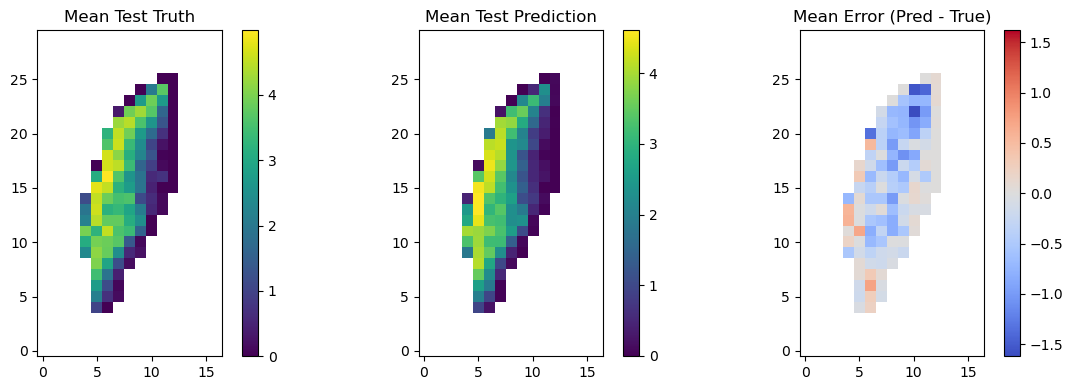

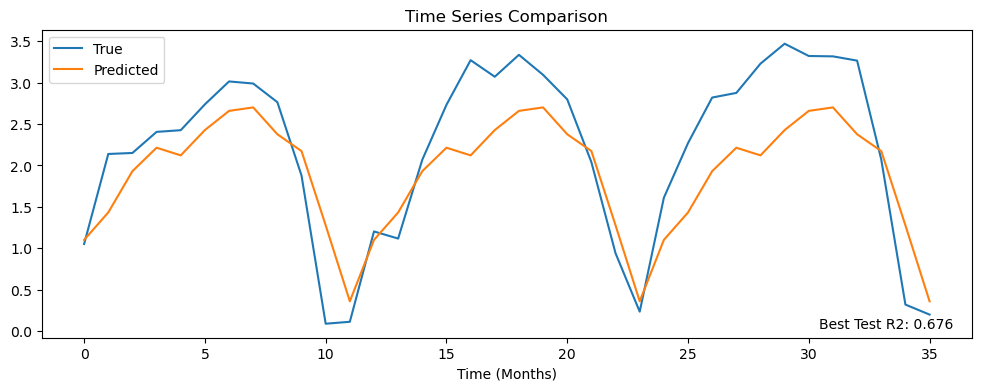

In [13]:
compute_climatology_metrics_regression(fishing_test, fishing_pred, mask_test)

In [14]:
# 1. Train/Test Split for the classification dataset (Split year 2020)

split_date = "2021-01-01"

fishing_class_train = fishing_class_cropped.sel(time=slice(None, split_date))
fishing_class_test = fishing_class_cropped.sel(time=slice(split_date, None))

# 2. Define a custom function to calculate the mode across a specific axis
def get_mode(x, axis):
    # scipy.stats.mode returns a tuple: (mode_array, counts_array)
    # We take index [0] to extract just the mode values.
    # keepdims=False ensures the dimensions align properly when xarray recombines them.
    return stats.mode(x, axis=axis, keepdims=False)[0]

# 3. Build the Climatology Model (Most frequent class per month from training set)
climatology_class = fishing_class_train.groupby("time.month").reduce(get_mode)

# 4. Predict on the Test Period
# Map the monthly mode back to the specific dates of the test set
fishing_class_pred = climatology_class.sel(month=fishing_class_test.time.dt.month).drop_vars("month")

In [15]:
def evaluate_climatology_classification(y_true_xr, y_pred_xr, mask_xr):
    # =====================================================
    # 0. PREPARE DATA (Extract numpy arrays from xarray)
    # =====================================================
    y_true = y_true_xr.values if hasattr(y_true_xr, 'values') else y_true_xr
    y_pred = y_pred_xr.values if hasattr(y_pred_xr, 'values') else y_pred_xr
    mask = mask_xr.values if hasattr(mask_xr, 'values') else mask_xr

    # Handle mask dimensions to ensure it matches the 3D shape (time, lat, lon)
    if mask.ndim == 2:
        mask_3d = np.broadcast_to(mask, y_true.shape)
    else:
        mask_3d = mask

    # Create the boolean spatial mask variable needed for the metrics and plotting
    mask_spatial = mask_3d.astype(bool)

    # =====================================================
    # 1. FLATTEN & MASK FOR METRICS
    # =====================================================
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    mask_flat = mask_spatial.flatten()

    y_true_masked = y_true_flat[mask_flat].astype(int)
    y_pred_masked = y_pred_flat[mask_flat].astype(int)

    # =====================================================
    # 2. CLASSIFICATION & SEGMENTATION METRICS
    # =====================================================
    unique_classes = np.unique(y_true_masked)
    
    print("=====================================================")
    print("CLASSIFICATION REPORT")
    print("=====================================================")
    report = classification_report(y_true_masked, y_pred_masked, labels=unique_classes, zero_division=0)
    print(report)

    # Calculate IoU and Kappa
    iou_per_class = jaccard_score(y_true_masked, y_pred_masked, average=None, labels=unique_classes)
    kappa = cohen_kappa_score(y_true_masked, y_pred_masked)

    print("=====================================================")
    print("SPATIAL SEGMENTATION METRICS")
    print("=====================================================")
    for i, cls in enumerate(unique_classes):
        if cls == 1:
            print(f"IoU Class 1 (Low CPUE):      {iou_per_class[i]:.3f}")
        elif cls == 2:
            print(f"IoU Class 2 (High CPUE):     {iou_per_class[i]:.3f}")
        else:
            print(f"IoU Class {cls}:                  {iou_per_class[i]:.3f}")
            
    print(f"Cohen's Kappa Score:         {kappa:.3f}\n")

In [16]:
evaluate_climatology_classification(
    y_true_xr=fishing_class_test, 
    y_pred_xr=fishing_class_pred, 
    mask_xr=mask_test
)

IndexError: boolean index did not match indexed array along dimension 0; dimension is 30600 but corresponding boolean dimension is 18360